In [1]:
import random
import shutil
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from PIL import Image
from src.utils.config import inject_config_vars, load_config
from src.utils.helpers import format_number, init_this_notebook, p

### Import configuration loader

In [2]:
# PROJECT_ROOT = None

# for parent in [Path.cwd(), *Path.cwd().parents]:
#     if (parent / "src").exists():
#         if str(parent) not in sys.path:
#             sys.path.append(str(parent))
#             print(f"Added to sys.path: {parent}")
#         PROJECT_ROOT = parent
#         break


# if PROJECT_ROOT is None:
#     raise RuntimeError("Could not locate project root (folder containing 'src').")

In [3]:
config = load_config()
inject_config_vars(config)


--- YAML Configuration ---
01: paths:
02:   root: C:\github\Tree-Canopy-Detection
03:   data: src/data
04:   train_images: src/data/train_images
05:   train_images_zip: src/data/train_images.zip
06:   train_masks: src/data/train_masks
07:   eval_images: src/data/evaluation_images
08:   eval_images_zip: src/data/evaluation_images.zip
09:   eval_masks: src/data/eval_masks
10:   models: models
11:   notebooks: notebooks
12: params:
13:   image_size: 512
14:   batch_size: 16
15:   num_workers: 0
16:   seed: 42
17:   epochs: 20
18:   learning_rate: 1e-4

Injected variables:
- ROOT: C:\github\Tree-Canopy-Detection, <class 'pathlib.WindowsPath'>
- PATHS_DATA: C:\github\Tree-Canopy-Detection\src\data, <class 'pathlib.WindowsPath'>
- PATHS_TRAIN_IMAGES: C:\github\Tree-Canopy-Detection\src\data\train_images, <class 'pathlib.WindowsPath'>
- PATHS_TRAIN_IMAGES_ZIP: C:\github\Tree-Canopy-Detection\src\data\train_images.zip, <class 'pathlib.WindowsPath'>
- PATHS_TRAIN_MASKS: C:\github\Tree-Canopy-D

In [4]:
init_this_notebook(SEED)

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]
Numpy: 1.26.4
Panda: 2.2.2



### Extract images and remove __MACOSX folders

In [5]:
# Mapping of zip files to their extraction targets
paths = {
    PATHS_TRAIN_IMAGES_ZIP: PATHS_TRAIN_IMAGES,
    PATHS_EVAL_IMAGES_ZIP: PATHS_EVAL_IMAGES,
}

# --- Extract zip archives ---
for zip_file, extract_to in paths.items():
    if not zip_file.exists():
        p("Zip file not found", zip_file)
        continue

    extract_to.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_file, "r") as zf:
        zf.extractall(extract_to)
    p("Extracted", f"{zip_file.relative_to(ROOT)} -> {extract_to.relative_to(ROOT)}")

    # Remove __MACOSX folders if present
    for macosx_dir in extract_to.rglob("__MACOSX"):
        if macosx_dir.is_dir():
            shutil.rmtree(macosx_dir)
            p("Removed: ", macosx_dir.relative_to(ROOT))

    print("")

Extracted: src\data\train_images.zip -> src\data\train_images
Removed: : src\data\train_images\__MACOSX

Extracted: src\data\evaluation_images.zip -> src\data\evaluation_images
Removed: : src\data\evaluation_images\__MACOSX



### Display one random image from each folder

No images found in src\data\train_images


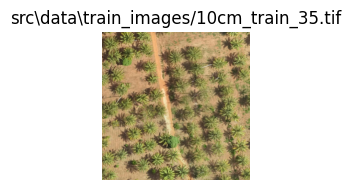

No images found in src\data\evaluation_images


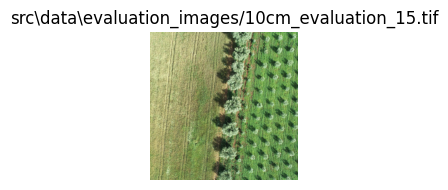

In [6]:
# preview
for folder in paths.values():
    if not folder.exists():
        print(f"Folder not found: {folder}")
        continue

    images = [
        f
        for f in folder.glob("*.*")
        if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
    ]
    if not images:
        p("", f"No images found in {folder.relative_to(ROOT)}")
        continue

    p("", f"No images found in {folder.relative_to(ROOT)}")

    img_path = random.choice(images)
    with Image.open(img_path) as img:
        plt.figure(figsize=(2, 2))
        plt.imshow(img)
        plt.title(f"{folder.relative_to(ROOT)}/{img_path.name}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

In [7]:
p("", "test")

test
